In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from sklearn.metrics import classification_report

In [2]:
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 25000
Testing samples: 25000


In [3]:
max_len = 200

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)


In [4]:
rnn_model = Sequential()
rnn_model.add(Embedding(vocab_size, 64, input_length=max_len))
rnn_model.add(SimpleRNN(64))
rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

print("\nTraining RNN model...")
history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2
)

C:\Users\Shivam\Downloads\Anaconda\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Training RNN model...
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.6515 - loss: 0.5928 - val_accuracy: 0.7992 - val_loss: 0.4599
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.8666 - loss: 0.3197 - val_accuracy: 0.8104 - val_loss: 0.4315
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9143 - loss: 0.2208 - val_accuracy: 0.8502 - val_loss: 0.3573


In [5]:
lstm_model = Sequential()
lstm_model.add(Embedding(vocab_size, 64, input_length=max_len))
lstm_model.add(LSTM(64))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(loss='binary_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

print("\nTraining LSTM model...")
history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2
)


Training LSTM model...
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 109ms/step - accuracy: 0.7748 - loss: 0.4642 - val_accuracy: 0.8586 - val_loss: 0.3381
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 110ms/step - accuracy: 0.8982 - loss: 0.2570 - val_accuracy: 0.8642 - val_loss: 0.3174
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 116ms/step - accuracy: 0.9277 - loss: 0.1962 - val_accuracy: 0.8620 - val_loss: 0.3433


In [6]:
print("\nRNN Evaluation")
rnn_pred = (rnn_model.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, rnn_pred))

print("\nLSTM Evaluation")
lstm_pred = (lstm_model.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, lstm_pred))


RNN Evaluation
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step
              precision    recall  f1-score   support

           0       0.85      0.86      0.85     12500
           1       0.86      0.84      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000


LSTM Evaluation
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step
              precision    recall  f1-score   support

           0       0.91      0.80      0.85     12500
           1       0.82      0.92      0.87     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



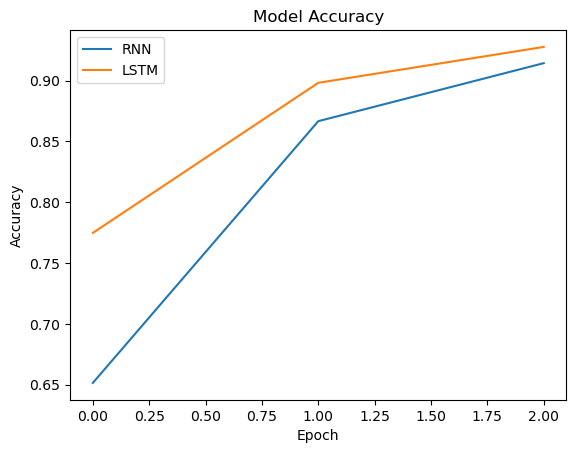

In [7]:
plt.plot(history_rnn.history['accuracy'])
plt.plot(history_lstm.history['accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['RNN', 'LSTM'])
plt.show()


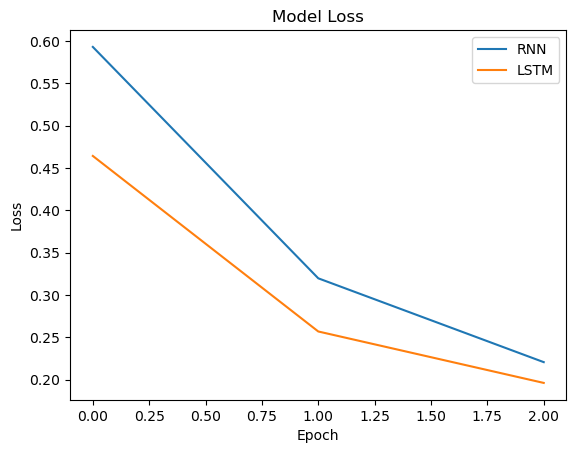

In [8]:
plt.plot(history_rnn.history['loss'])
plt.plot(history_lstm.history['loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['RNN', 'LSTM'])
plt.show()